Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Step 2: Upload Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


Step 3: Load Dataset

In [ ]:
df = pd.read_csv("diabetes.csv")

df.head()
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0
768,1,93,70,31,0,30.4,0.315,23,0


Step 4: Understand the Dataset

In [ ]:
df.shape

(769, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               769 non-null    int64  
 1   Glucose                   769 non-null    int64  
 2   BloodPressure             769 non-null    int64  
 3   SkinThickness             769 non-null    int64  
 4   Insulin                   769 non-null    int64  
 5   BMI                       769 non-null    float64
 6   DiabetesPedigreeFunction  769 non-null    float64
 7   Age                       769 non-null    int64  
 8   Outcome                   769 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.2 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,769.000000,764.000000,734.000000,542.000000,394.000000,758.000000,769.000000,769.000000,769.000000
mean,3.841352,121.649215,72.401907,29.156827,155.548223,32.454749,0.471672,33.227568,0.348505
std,3.368946,30.533268,12.374028,10.467595,118.775855,6.920816,0.331161,11.758373,0.476807
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.371000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626000,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Step 5: Check Missing Values

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,375
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Step 6: Data Cleaning

Replace impossible zero values with NaN.

In [ ]:
columns = ['Glucose',
           'BloodPressure',
           'SkinThickness',
           'Insulin',
           'BMI']

df[columns] = df[columns].replace(0, np.nan)

df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1
767,1,93.0,70.0,31.0,NaN,30.4,0.315,23,0


Fill missing values using the median.

In [ ]:
for col in columns:
    df[col] = df[col].fillna(df[col].median())

Verify missing values.

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Step 7: Exploratory Data Analysis (EDA)
Class Distribution

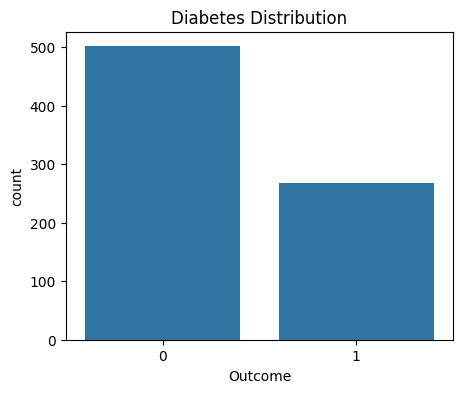

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(x='Outcome', data=df)

plt.title("Diabetes Distribution")

plt.show()

Correlation Heatmap

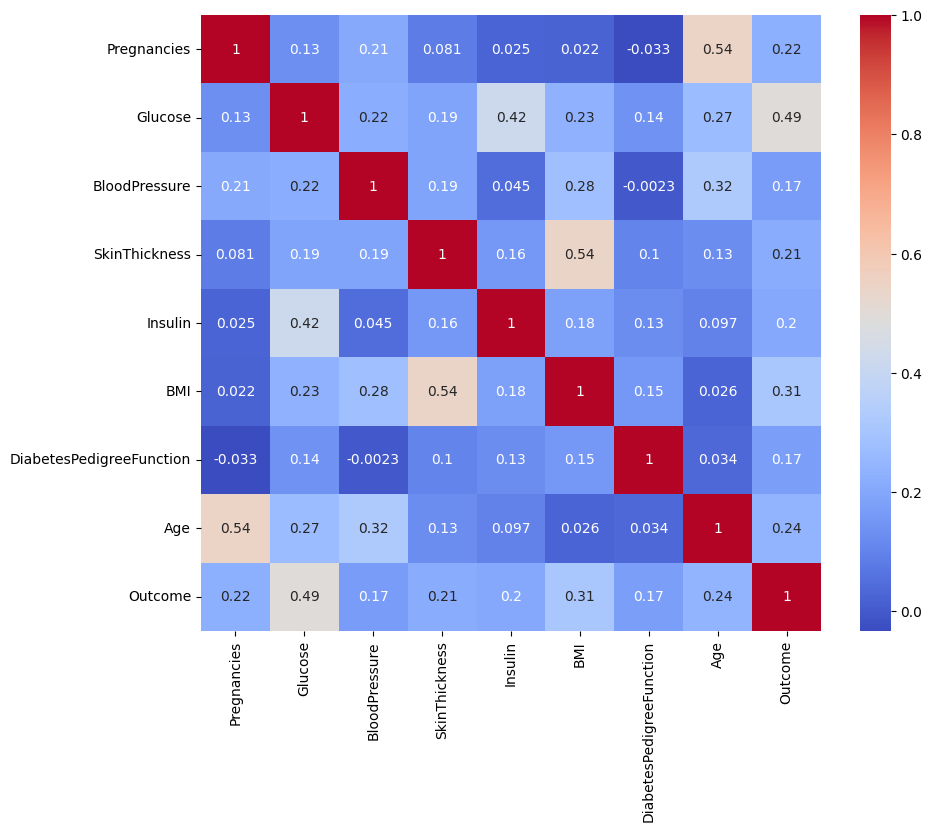

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

Histograms

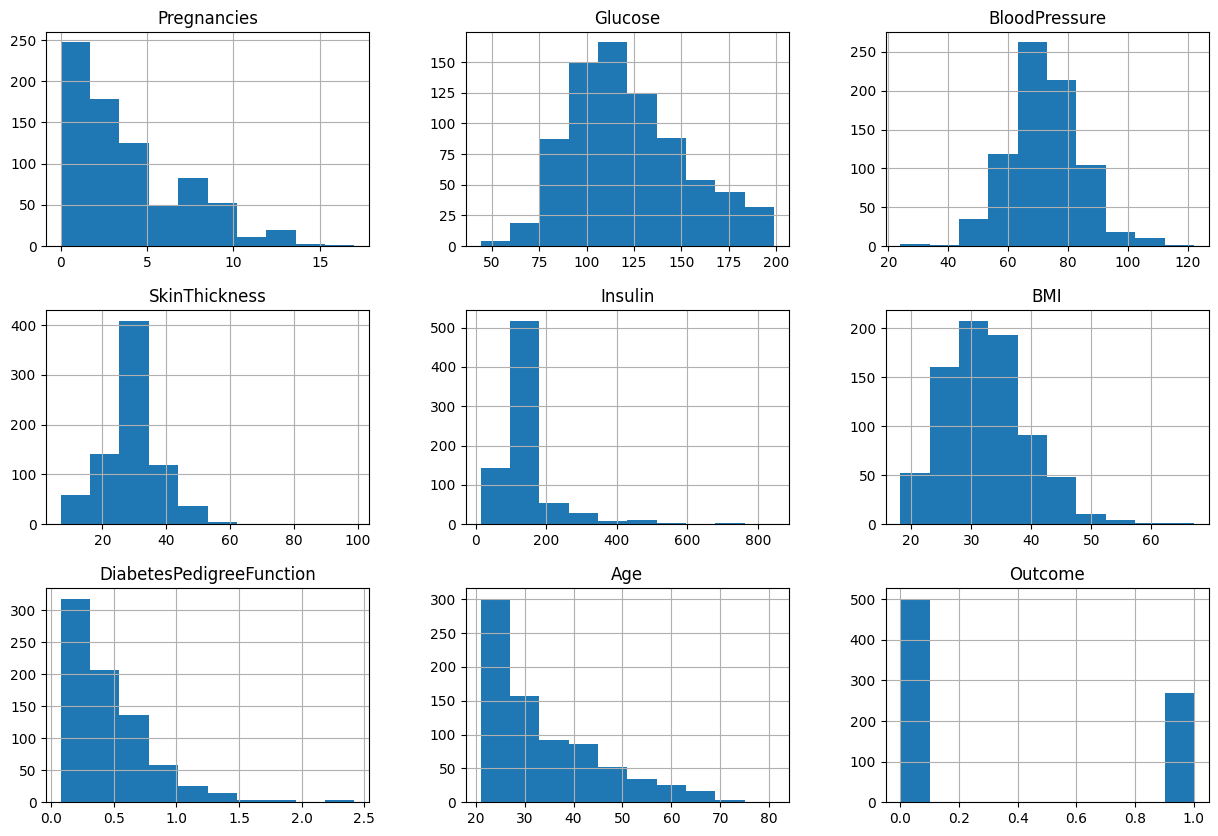

In [ ]:
df.hist(figsize=(15,10))

plt.show()

Boxplots

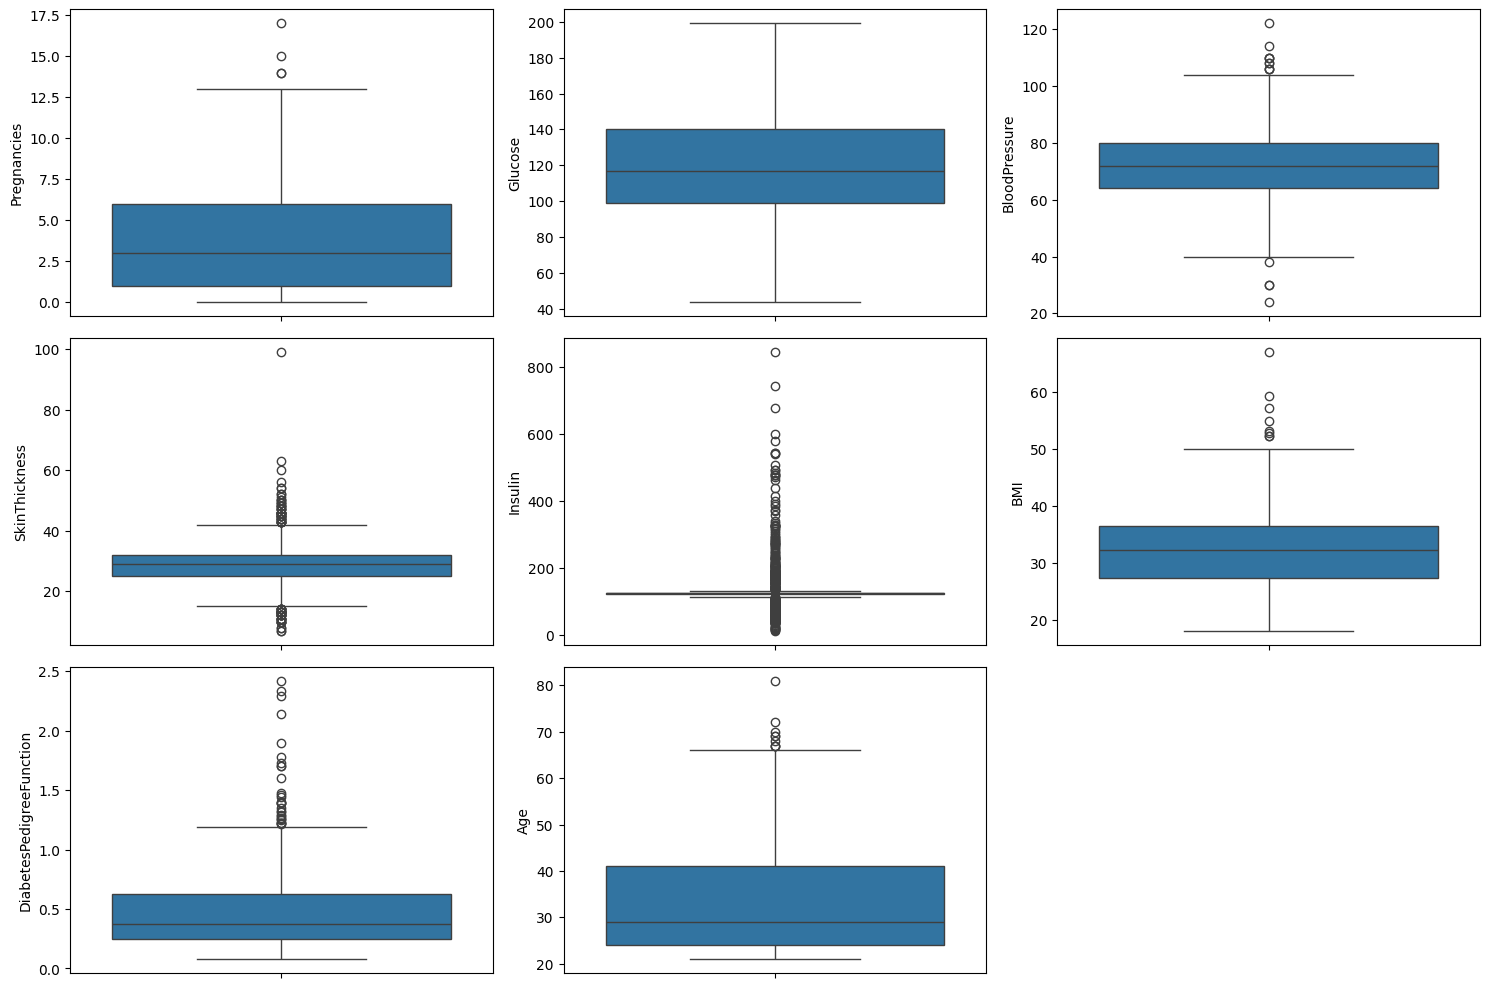

In [ ]:
plt.figure(figsize=(15,10))

for i, column in enumerate(df.columns[:-1]):

    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[column])

plt.tight_layout()

plt.show()

Step 8: Feature Selection

In [ ]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

Step 9: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Step 10: Train Naïve Bayes Model

In [ ]:
model = GaussianNB()

model.fit(X_train, y_train)

GaussianNB()

Step 11: Predict Test Data

In [ ]:
y_pred = model.predict(X_test)

Step 12: Model Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.7532467532467533


Step 13: Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[78 22]
 [16 38]]


Visualize

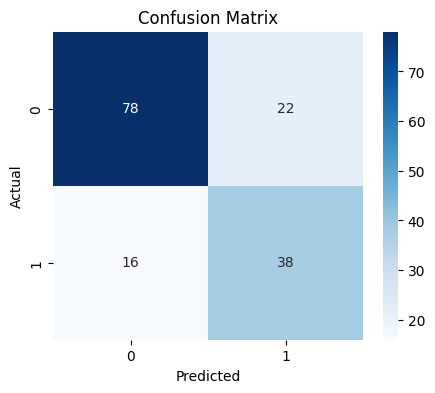

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Step 14: Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.78      0.80       100
           1       0.63      0.70      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.74       154
weighted avg       0.76      0.75      0.76       154



Test

In [ ]:

new_patient = [[
    2,
    150,
    80,
    30,
    120,
    28,
    0.50,
    50
]]

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Prediction: Diabetes")
else:
    print("Prediction: No Diabetes")

Prediction: Diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


                 Diabetes Dataset
                         │
                         ▼
                 Load Dataset
                         │
                         ▼
               Understand Dataset
                         │
                         ▼
                Data Cleaning
                         │
                         ▼
          Replace Missing Values
                         │
                         ▼
               Exploratory Data Analysis
                         │
                         ▼
               Feature Selection
                         │
                         ▼
               Train-Test Split
                         │
                         ▼
           Gaussian Naïve Bayes Model
                         │
                         ▼
                  Model Training
                         │
                         ▼
                    Prediction
                         │
                         ▼
             Accuracy Evaluation
                         │
                         ▼
             Confusion Matrix
                         │
                         ▼
           Classification Report
                         │
                         ▼
             Predict New Patient